# Narrative Scene Decoding

### Ian Henriques -- NEU 480 Final Project

In [1]:
# Extra libraries installed in /scratch
import sys
sys.path.insert(0, '/scratch/network/ih2422/lib')

# Importing functions from other files
import importlib
import narratives_utils
importlib.reload(narratives_utils)

# Pathlib for handling file paths
from pathlib import Path

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Pandas for data manipulation
import pandas as pd

# Display DataFrames without the index column (I saw this trick online)
pd.DataFrame._repr_html_ = lambda self: self.style.hide(axis="index").to_html()

# NumPy for numerical operations
import numpy as np

# Scipy for statistical tests
from scipy import stats

# Statsmodels for multiple comparisons correction
from statsmodels.stats.multitest import multipletests

# Regular expressions for string manipulation
import re

# Sklearn for machine learning tools
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut

# Nilearn for neuroimaging data handling
from nilearn import plotting, surface, datasets
from nilearn.image import resample_to_img, new_img_like
from nilearn.maskers import NiftiMasker

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress nilearn info-level logs (e.g. dataset found messages)
import logging
logging.getLogger('nilearn').setLevel(logging.WARNING)

### Abstract:

Many regions in the brain, including the place network (PPA, RSC, and OPA) and default mode network (including the mPFC, AG, and PMC), are known to be involved in encoding scene context during audiovisual stimuli. However, it has not been shown that for purely auditory stimuli (i.e., narratives with repeated scene structure), fMRI brain activity is sufficient to decode the current narrative scene. In this study, we analyze Tunnel Under the World (<u>Lositsky et al., 2016</u>; <u>Nastase et al., 2021</u>), a story that cycles between three narrative locations across 8 total scene segments, to determine the extent to which fMRI activity in various areas can predict the identity of each scene. We find that across 20 subjects, several regions show significant above-chance decoding, with the mPFC and PPA showing the strongest effects (mean accuracy 0.61 and 0.53 respectively, chance = 0.33) among scene-related regions we look for. Across multiple subjects, 18 of 60 cortical parcels survive FDR correction (q = 0.01) of decoding performance, concentrated in the default mode network and part of the place network. Representational similarity analysis further reveals structured scene geometry in both the PPA and mPFC. These results demonstrate that even when visual inputs are absent, the mPFC, PPA, and other scene-relevant regions play a role in maintaining and reinstating scene context during stories.

# Introduction

The Narratives dataset (<u>Nastase et al., 2021</u>) contains stimulus-aligned and motion-corrected fMRI data for several naturalistic stories. This large dataset enables many downstream studies, including decoding story attributes (like the current speaker or emotional valence) from fMRI data timeseries across several subjects.

One of these stories, Tunnel Under the World (`tunnel` for short), comprises 23 subjects prior to filtering, with 25 minutes of data per subject (<u>Lositsky et al., 2016</u>). For the first 14 minutes, the story has a main character named Guy Burkhardt, who experiences each day repeating like the last, cycling through the same three scenes -- Guy's **home**, the **bus**, and his **office** -- until the plot suddenly changes. During this first half of the story, successful comprehension may require subjects to re-instate their models of each scene, so that strange occurrences (such as explosions in Guy's cellar) can be related across different instances of the same scene.

Given this intuition of three scene models that are established and updated at specific points throughout the story, similar to event models (<u>Baldassano et al., 2017</u>), we hypothesize that brain representations (and hence BOLD activity) would be sufficiently separable across scenes to allow a decoder to predict the scene being referred to when each scene begins. Further, we predict that regions typically recruited during *visual* or *audiovisual* scene recognition tasks, such as those in the place network (including the Parahippocampal Place Area, PPA/PHC for short) and the default mode network (including the medial Pre-Frontal Cortex, mPFC for short) would contain scene-specific representations that allow for classification of the correct scene.

Prior fMRI studies of narrative comprehension have examined event structure and temporal patterns in high-level cortical regions (<u>Baldassano et al., 2018</u>; <u>Lerner et al., 2011</u>), but have not directly tested whether the occurrences of the **same scene** can be decoded across event boundaries in a story. Meanwhile, other work has shown that occurrences of the same scene in an *audiovisual* stimulus can have high similarity in certain brain regions (<u>Milivojevic et al., 2016</u>). To our knowledge, the role of scene-relevant regions in decoding scene identity during purely auditory stimuli (e.g., narratives) has not been previously studied in the literature; we investigate it for the first time here.

The specific research questions we aim to answer are:
1. *Can the identity of a recurring scene in an auditory narrative be decoded from fMRI brain activity?*
2. *If so, which brain regions carry the strongest scene-specific representations?*

To test claims of scene decodability, we split the first half of the `tunnel` story into eight distinct *instances*, which represent occurrences of the three scenes: 3 home instances, 3 bus instances, and 2 office instances. Then, we apply standard decoding methods -- support vector machines fit on instance-averaged activity, as well as RSA to quantify scene similarity across instances -- across one subject and several subjects.

Our results show that within-subject scene decoding performance is both *localized to scene-relevant regions* and *statistically significant (when averaged across subjects)*. These findings suggest that scene-relevant regions may have a functional role in maintaining scene-relevant context across different occurrences of the same scene.

# Methods

## Participants

For this study, we begin with 23 participants whose data is present in the Narratives dataset (<u>Nastase et al., 2021</u>). These subjects are fetched from the `sub-###` folders -- subjects which have `func/sub-###_task-tunnel_bold.nii.gz` entries have valid fMRI data from the `tunnel` story. As per the recommendation in the Narratives dataset, we exclude two subjects whose data are of lower quality: `sub-004` and `sub-013`.

In [2]:
# Fetch all tunnel subjects
tunnel_subjects = narratives_utils.fetch_subject_list(
    "tunnel",
    exclude_subjects=["sub-004", "sub-013"]
)
print("Loaded tunnel subjects:", tunnel_subjects)

Loaded tunnel subjects: ['sub-001', 'sub-005', 'sub-022', 'sub-025', 'sub-026', 'sub-041', 'sub-052', 'sub-053', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062', 'sub-063', 'sub-064', 'sub-065', 'sub-066', 'sub-069']



As a further quality control step, we also use whole-brain inter-subject correlation (ISC) to filter out subject(s) whose ISC is lower than usual (<u>Hasson et al., 2004</u>, <u>Nastase et al., 2019</u>). This is a common step in functional MRI pipelines that involve multiple subjects, hinging on the assumption that subjects with lower ISC with other subjects may be distracted from the stimulus or may have more pronounced motion artifacts.

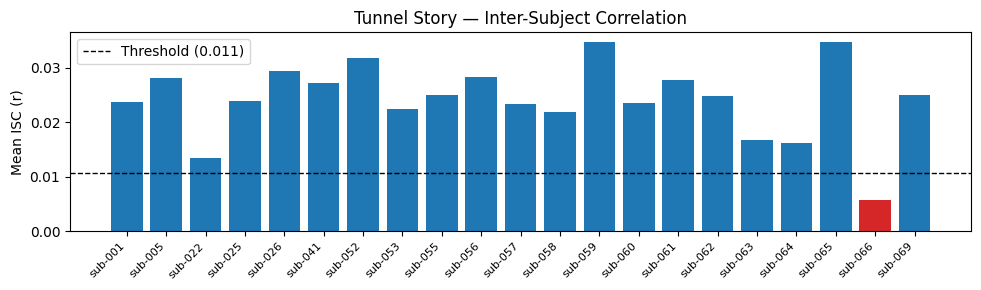

In [3]:
# ISC-based attention filter (based on the ISC approach described in Hasson et al., 2004)
_mni = datasets.load_mni152_brain_mask(resolution=4)
isc_scores, tunnel_subjects_filtered = narratives_utils.isc_filter(
    tunnel_subjects,
    "tunnel",
    _mni,
    title="Tunnel Story — Inter-Subject Correlation"
)

Subject `sub-066` has a mean ISC that is more than two standard deviations below the group mean, suggesting worse BOLD data quality for this specific subject. For this reason, we drop this subject from our analyses.

This leaves **20** subjects after filtering. It is important to note that while filtering subjects, we never exclude subjects on the basis of scene decoding performance; doing so would lead to leakage and over-optimistic results. The remaining subjects are included in every across-subject experiment, regardless of their agreement with our hypotheses.

## Stimuli

All 20 subjects in our study are exposed to the same stimulus: Tunnel Under the World (25 minutes, 34 seconds). Pre-compiled transcripts are available in the Narratives dataset, in the `stimuli/whisperx` folder. By concatenating the `word` fields of `tunnel`'s JSON file, we can derive a plaintext transcript:

In [4]:
# Fetch the transcript from whisperx
whisperx_transcript = narratives_utils.fetch_whisperx_transcript("tunnel")

# Print the beginning of the story
print(whisperx_transcript[:100] + "...")

Tonight, a story by Frederick Pohl, Tunnel Under the World. On the morning of June 15, Guy Burkhardt...


To perform scene decoding, we split the transcript by finding scene instance boundaries using an LLM (Claude Sonnet 4.6). The prompt emphasizes that the language model must find *scene onsets* that could elicit mental images in subjects (such as "in the kitchen, cooking breakfast"). We secure the Claude API key using a vault (to ensure it remains safe on the cluster), then annotate and cache the scenes exactly once with an API call. The result is a set of excerpts which correspond to scene onsets. We manually validate and tweak these scene onsets in the corresponding tab-separated file, where necessary.

In [5]:
# Either annotate the scenes, or read the cached result
out_path = narratives_utils.out_dir / "tunnel_scenes.tsv"
tunnel_scenes = narratives_utils.annotate_scenes(
    "Tunnel Under the World",
    narratives_utils.fetch_whisperx_transcript("tunnel"),
    ["home", "bus", "office"],
    out_path
)

Then, based on the scene onset excerpts, we perform careful scanning of the whisperx transcript's timing using string searching, to determine when each scene instance begins and ends. This helps obtain a start and end timestamp (both in seconds) for each scene instance, such that the end timestamp of one event is the start of the next:

In [6]:
# Fetch the segments for the tunnel story, from the .tsv file from the previous cell
tunnel_segments = narratives_utils.fetch_segments("tunnel")

# Align the annotated scenes to the segments, using the whisperx transcript
tunnel_aligned = narratives_utils.align_tsv_to_whisperx(
    Path("tunnel_scenes.tsv"),
    tunnel_segments,
    narratives_utils.fetch_whisperx_transcript("tunnel")
)

# Print out a table of tunnel segments, with their start and end times
pd.DataFrame(tunnel_aligned)

scene,start,excerpt,end
home,41.855000,"In the kitchen, cooking breakfast.",78.614000
bus,78.614000,"Coming in on the bus,",126.901000
office,126.901000,"the gigantic Contro Chemical building,",224.216000
home,224.216000,got ready for bed.,325.807000
bus,325.807000,took the usual bus to work.,376.447000
office,376.447000,The speaker in the elevator,647.532000
home,647.532000,Guy Burkhart went home,813.766000
bus,813.766000,Guy Burkhardt got on his bus.,859.107000
other,859.107000,"Burkhardt. Here, behind the fence.",1517.970000


The "other" scene category refers to the second half of the story, which does not contain meaningful repetition of scenes. This table can be equivalently shown in the following timeline plot, with a single row per scene category (home, bus, office):

In [7]:
# Colors for the timeline plot
tunnel_colors = {
    "home": "#4C72B0",
    "bus": "#DD8452",
    "office": "#55A868",
    "other": "#bbbbbb"
}

# Labeled scene names
labeled_scenes = ["home", "bus", "office"]

# Instances (ignoring "other" scenes)
instances = [row for row in tunnel_aligned if row["scene"] in labeled_scenes]

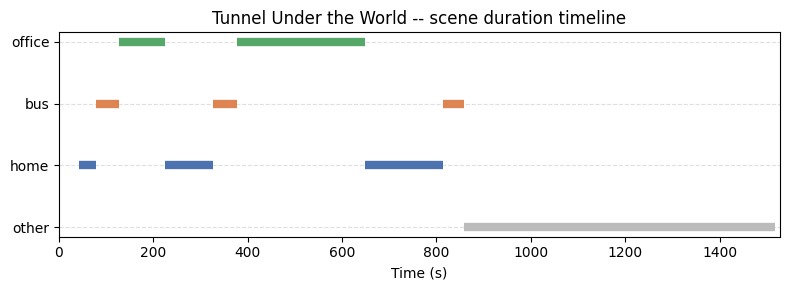

In [8]:
# Plot the scene timeline for the tunnel story
narratives_utils.plot_scene_timeline(
    tunnel_aligned,
    "Tunnel Under the World -- scene duration timeline",
    labeled_scenes,
    tunnel_colors
)

Plotting just the instance onsets (from the start to 10 seconds after the start) helps identify the timing of scene onsets:

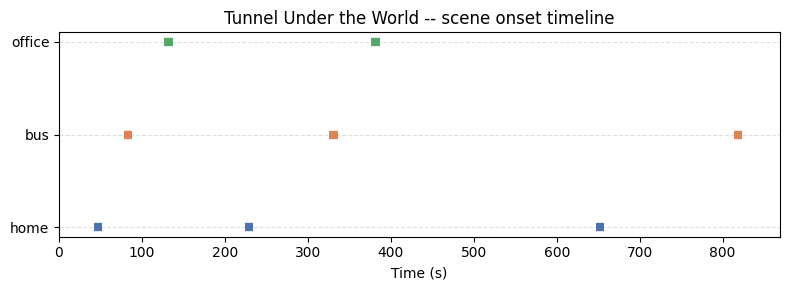

In [9]:
# Plot instance onsets for the tunnel story
narratives_utils.plot_instance_onsets(
    instances,
    "Tunnel Under the World -- scene onset timeline",
    labeled_scenes,
    tunnel_colors
)

For each instance, we use BOLD activity averaged over the *onset* of the instance, rather than the average BOLD activity over the whole instance (i.e., the instance duration). Constructing instance-level BOLD activity for the onsets alone gives us three advantages over the entire instance duration:
1. Since instance onsets are fully non-overlapping, we do not accidentally average activity from multiple scenes when computing the mean BOLD of each instance.
2. Instance onsets do not contain musical or sound effect cues, which could be a potential confounding variable if instance duration were used instead.
3. If we expect subjects to form "mental pictures" that can be decoded using fMRI, we should narrow the stimulus length to only include specific language (at the instance onsets) that elicits mental pictures.

In summary, our effective stimuli (after LLM annotation, transcript alignment, and narrowing to scene onsets) are eight scene instances, each consisting of 10 seconds of brain activity after language that would conjure a mental image of a scene.

## fMRI Data Preprocessing

Since the Narratives dataset already performed motion correction, MNI normalization, and nuisance signal regression, our preprocessing pipeline is simpler compared to papers that collect data from scratch.

Each subject's data is loaded using a custom function we created, `load_bold_masked`. This function can load in BOLD data normally (using BIDS), but can also cache BOLD data for a subject after Nifti masking and other steps (including a resolution change to 4mm). This caching scheme significantly speeds up development, resulting in ~1 second to load BOLD data per subject, rather than ~30 seconds. Caching does not affect performance, since masking and resolution changes are deterministic. Standardization is used (z-scoring each subject's BOLD data across time), to partially account for subject-level scanner drift.

In [10]:
# Load the MNI brain mask at 4mm resolution for later use in loading and processing fMRI data
mni_mask = datasets.load_mni152_brain_mask(resolution=4)

We also account for differences between fMRI and stimulus timing, by hard-coding the Narratives dataset's TR length (1.5 seconds) and hemodynamic lag (4 TRs, or 6 seconds). When loading the averaged BOLD data per instance, we explicitly account for hemodynamic lag by incrementing (by 4) the start and end TRs of the 10-second window corresponding to the instance.

In [11]:
# Constants for fMRI data processing
TR          = 1.5
HRF_LAG_TRS = 4

def instance_BOLD(instance, bold):
    """
    Extract the mean BOLD pattern for a given scene instance, accounting for the hemodynamic lag.

    Parameters:
    - instance: dict
        A dictionary containing 'start' and 'end' times (in seconds) for the scene instance.
    - bold: np.ndarray [n_timepoints, n_voxels]
        Contains the BOLD signal for a subject, already masked to the voxels of interest.

    Return:
    ------
    mean: np.ndarray [n_voxels]
        A 1D NumPy array containing the mean BOLD pattern for the given scene instance.
    """
    start_tr = int(instance["start"] / TR) + HRF_LAG_TRS
    # end_tr   = int(instance["end"]   / TR) + HRF_LAG_TRS
    start_onset_tr, end_onset_tr = start_tr, start_tr + 10
    start_onset_tr = max(0, min(start_onset_tr, len(bold) - 1))
    end_onset_tr   = max(start_onset_tr + 1, min(end_onset_tr, len(bold)))
    return bold[start_onset_tr:end_onset_tr].mean(axis=0)

## ROI Construction

We use the Schaefer atlas (400 parcels, 17 networks) for labeling and grouping regions, which helps specify scene-relevant ROIs such as the PPA and mPFC (<u>Schaefer et al., 2018</u>).

For instance, for the PPA, the corresponding Schaefer name is `PHC`. For every one of the parcels with `PHC` in the name (ensuring no other ROI prefixes are triggered), we add them to a growing volume mask, then store that mask for later. Similarly, the mPFC would contain `PFCm` in its Schaefer name -- all parcels containing `PFCm` could be merged, allowing for ROI-specific BOLD activity to be merged as well.

In total, we calculate 10 ROIs. One of these is (trivially) the **Whole Brain**, containing all other parcels. We include three regions from the place network: **PPA** (parahippocampal place area), **RSC** (retrosplenial cortex), **OPA** (occipital place area). Three are from the default mode network: **mPFC** (medial prefrontal cortex), **AG** (angular gyrus), and **PMC** (posterior medial cortex). The final three are low-level regions which serve as controls (we would expect their scene decoding performance to be close to chance): **A1** (primary auditory cortex), **V1** (primary visual cortex), and **S1** (primary somatosensory cortex).

In [12]:
# Schaefer atlas for parcellation and ROI definition
schaefer_atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=400,
    yeo_networks=17,
    resolution_mm=2,
    verbose=0
)

# Labels for the parcels
schaefer_labels = [l.decode() if isinstance(l, bytes) else l for l in schaefer_atlas.labels]
parcel_labels = {i + 1: lbl for i, lbl in enumerate(schaefer_labels)}

# Build the atlas
ref_masker = NiftiMasker(mask_img=mni_mask, standardize=True)
ref_masker.fit()
schaefer_img  = resample_to_img(
    schaefer_atlas.maps,
    ref_masker.mask_img_,
    interpolation='nearest'
)
schaefer_data = schaefer_img.get_fdata().astype(int)
mask_data     = ref_masker.mask_img_.get_fdata().astype(bool)

# Define ROIs to be used for decoding
roi_searches = [
    ("Whole Brain", [""]),
    ("PPA",         ["PHC"]),
    ("RSC",         ["Rsp"]),
    ("OPA",         ["DorsAttnA_TempOcc", "DorsAttnB_TempOcc"]),
    ("mPFC",        ["PFCm"]),
    ("AG",          ["DefaultB_IPL", "DefaultC_IPL"]),
    ("PMC",         ["_pCun"]),
    ("A1",          ["SomMotB_Aud"]),
    ("V1",          ["Striate"]),
    ("S1",          ["SomMotA"]),
]

# Build masks for each ROI by combining the relevant parcels and applying the brain mask
roi_masks = {}
for roi, searches in roi_searches:
    vol = np.zeros(schaefer_data.shape, dtype=bool)
    for idx, lbl in parcel_labels.items():
        if any(s in lbl for s in searches):
            vol |= (schaefer_data == idx)
    roi_masks[roi] = vol & mask_data

In addition to the 10 ROIs, we compute decoding accuracy for each of the 400 individual Schaefer parcels and 60 **parcel groups**. Parcel groups are formed by merging parcels that share a name prefix across hemispheres (e.g., all parcels matching `*_DefaultA_PFCm_*` form one group), yielding finer granularity than the 17 networks while still grouping similar parcels together. This enables whole-brain surface maps of scene decodability without restricting analysis to predefined ROIs.

In [13]:
def parcel_to_group(lbl):
    """
    Convert a Schaefer parcel label to its corresponding network group.

    Parameters:
    ----------
    lbl: str
        Schaefer parcel label.

    Return:
    ------
    group: str
        Network group corresponding to the Schaefer parcel label.
    """
    lbl = re.sub(r'^17Networks_[LR]H_', '', lbl)
    lbl = re.sub(r'_\d+$', '', lbl)
    return lbl

parcel_groups = {
    idx: parcel_to_group(lbl)
    for idx, lbl in parcel_labels.items()
    if parcel_to_group(lbl) != 'Background'
}

# Group to list of parcel indices
group_parcel_lists = {}
for idx, g in parcel_groups.items():
    group_parcel_lists.setdefault(g, []).append(idx)

## Single-Subject Scene Decoding

To test decoding performance, we begin with a single subject, `sub-001`, to determine the extent to which the correct scenes can be decoded across instances.

To build the input BOLD signal for each instance, we calculate time-averaged BOLD activity within the onset of the instance (from the start time to 10 seconds after start), as mentioned in Section <u>fMRI Data Preprocessing</u>. For region-specific analyses, we first apply a mask to select the specific ROI (see Section <u>ROI Construction</u>), then calculate the time-averaged instance BOLD signal. For labels, we use the known labels from the <u>Stimuli</u> section, corresponding to the scene category of each instance.

In [14]:
def build_X(instances, bold):
    """
    Build the feature matrix X for instances and corresponding BOLD data.

    Parameters:
    ------
    instances: list of dict
        List of scene instances, each with 'start' and 'end' times.
    bold: np.ndarray [n_timepoints, n_voxels]
        Contains the BOLD signal for a subject, already masked to the voxels of interest.

    Return:
    ------
    X: np.ndarray [n_instances, n_voxels]
        Feature matrix for the instances.
    """
    return np.vstack([instance_BOLD(instance, bold) for instance in instances])

# Encode labels once — same for every subject
y = LabelEncoder().fit_transform([instance["scene"] for instance in instances])
num_classes = np.unique(y).size

Since we only have 8 instances overall, we use LOOCV (Leave-One-Out Cross-Validation) over the instances, to calculate the held-out scene decoding accuracy of each instance, when training on the others. This helps ensure that scene decoding is high for *every* instance, compared to a randomized train-test-split approach that would only evaluate on a smaller subset of instances.

For each of the 8 instance-level folds, we first apply a `StandardScaler` object, to scale each voxel of the training BOLD inputs to a more consistent range.

Then, we fit a `LinearSVC` (Linear Support Vector Classifier) on the scaled instances, since `LinearSVC` tends to perform well on other decoding tasks when the number of voxels is much larger than the number of instances.

In [15]:
def evaluate_decoding(X, y):
    """
    Evaluate the decoding accuracy for a given dataset using leave-one-out cross-validation.

    Parameters:
    ------
    X: np.ndarray [n_instances, n_voxels]
        Feature matrix for the instances.
    y: np.ndarray [n_instances]
        Target labels for the instances.

    Return:
    ------
    accuracy: float
        Decoding accuracy (proportion of correctly classified instances).
    """

    # Pipeline with standard scaling and linear SVM classifier
    pipe  = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    LinearSVC(max_iter=10000))
    ])

    # Leave-One-Out cross-validation (leave out each instance once)
    loo   = LeaveOneOut()

    # Iterate through each train/test split
    preds = []
    for train_idx, test_idx in loo.split(X):
        pipe.fit(X[train_idx], y[train_idx])
        pred = pipe.predict(X[test_idx])[0]
        preds.append(pred)
    return np.mean(np.array(preds) == y)

def evaluate_decoding_perm(X, y, n_perm=100, rng=None):
    """
    Evaluate decoding accuracy and compute a permutation-test p-value.

    Parameters:
    ----------
    X: np.ndarray [n_instances, n_voxels]
        Feature matrix for the instances.
    y: np.ndarray [n_instances]
        Target labels for the instances.
    n_perm: int
        Number of label permutations used to build the null distribution.
    rng: np.random.Generator or None
        Random number generator. If None, uses np.random.default_rng().

    Return:
    ------
    obs: float
        Observed decoding accuracy under true labels.
    p: float
        p-value: fraction of permuted accuracies >= observed accuracy.
    null_mean: float
        Mean accuracy across all permutations (empirical chance level).
    """
    if rng is None:
        rng = np.random.default_rng()

    loo = LeaveOneOut()

    def _loo_acc(labels):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm",    LinearSVC(max_iter=10000))
        ])
        preds = []
        for train_idx, test_idx in loo.split(X):
            pipe.fit(X[train_idx], labels[train_idx])
            preds.append(pipe.predict(X[test_idx])[0])
        return np.mean(np.array(preds) == labels)

    obs  = _loo_acc(y)
    null = [_loo_acc(rng.permutation(y)) for _ in range(n_perm)]
    p    = np.mean(np.array(null) >= obs)
    return obs, p, float(np.mean(null))

Overall, the **decoding accuracy** is equal to the averaged held-out accuracy across all 8 instances. For each ROI (the 10 broader regions defined in <u>ROI Construction</u>, as well as each of the 400 parcels and 60 groups in the Schaefer parcellation), we compare this decoding accuracy to the chance level (1/3 = 0.333...), which would be the expected accuracy if labels are assigned in a uniformly random fashion.

Since we only consider one subject at first, we do not initially calculate error bars for ROI-specific decoding performance, which is a limitation of the single-subject approach.

## Averaged Within-Subject Decoding

To aggregate results across subjects, we run the same LOOCV pipeline over all 20 subjects independently, computing the decoding accuracy for each subject. Then, we compute the mean and standard error of decoding accuracy for each of the 10 main ROIs, with the standard error terms serving as error bars on our bar charts.

We also perform an extension of this analysis to the 60 Schaefer parcel groups. For each group, we test whether the mean accuracy across subjects is significantly above chance using 100K sign-flip permutation tests: subject-level accuracies are centered around chance, then their signs are randomly flipped to simulate what the group mean would look like if there were no scene-specific information in that region. The p-value is the fraction of simulated means at least as large as the observed mean. We also apply a stringent FDR (false discovery rate) correction (q=0.01) to limit the expected proportion of false discoveries among significant regions to 1%.

## Scene-Level RSA

To study a different angle of scene decoding performance, we can treat each scene instance onset as a stimulus, then plot an RSA (Representational Similarity Analysis) plot for each ROI. For each subject, we extract the same instance-averaged BOLD patterns used in decoding and compute their 8×8 pairwise Pearson correlation matrix; these matrices are then averaged across all 20 subjects. We choose two regions, the PPA and mPFC, due to their relatively high decoding performances and the fact that they serve as representative regions for the place and default-mode networks, respectively.

We create two sets of RSA plots: one where the diagonal is nonzero (to include self-correlations) and the other where the diagonal is nulled (to focus on similarities between different instances). Instances are sorted by scene category so that within-scene pairs form blocks along the diagonal, with black lines marking category boundaries. We expect that in all plots, instances of the same scene category (i.e., blocks closer to the diagonal) would have more similar averaged BOLD responses compared to different scenes.

In [16]:
# Sort events by scene label
scene_labels  = [instance["scene"] for instance in instances]
sort_order    = sorted(range(len(instances)), key=lambda i: scene_labels[i])
sorted_labels = [scene_labels[i] for i in sort_order]

# Group boundary positions
counts, prev = [], None
for lbl in sorted_labels:
    if lbl != prev:
        counts.append(1)
        prev = lbl
    else:
        counts[-1] += 1

def plot_rsa(ax, matrix, title, exclude_diagonal=False):
    """Plot RSA matrix for a given region.

    Parameters:
    ----------
    ax: matplotlib axes
        Axes object for plotting.
    matrix: numpy array
        RSA matrix to plot.
    title: str
        Title for the plot.
    exclude_diagonal: bool, optional
        Whether to exclude the diagonal values from the plot.

    Return:
    ------
    img: matplotlib image
        The image object created by imshow, for use in colorbar.
    """

    # Get the order of parcels based on their groupings
    mat_sorted = matrix[np.ix_(sort_order, sort_order)].copy()

    # Exclude diagonal values if specified, and set color limits accordingly
    if exclude_diagonal:
        np.fill_diagonal(mat_sorted, np.nan)

        # Symmetric color scale based on max absolute value
        vmax = np.nanmax(np.abs(mat_sorted))
        img = ax.imshow(mat_sorted, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    else:
        img = ax.imshow(mat_sorted, cmap='RdBu_r', vmin=-1, vmax=1)

    # Add lines to separate groups
    cumul = 0
    for c in counts[:-1]:
        cumul += c
        ax.axhline(cumul - 0.5, color='k', linewidth=1.5)
        ax.axvline(cumul - 0.5, color='k', linewidth=1.5)

    # Set ticks and labels
    ax.set_xticks(range(len(sorted_labels)))
    ax.set_yticks(range(len(sorted_labels)))
    ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(sorted_labels, fontsize=9)
    ax.set_title(title)

    return img

# Results

## Single-Subject Scene Decoding Performance

In [17]:
subject_acc = {}

for sub_i in tunnel_subjects_filtered:
    data_i = narratives_utils.load_bold_masked(sub_i, "tunnel", mni_mask, standardize=True)
    if data_i is None:
        print(f"{sub_i}  — file missing, skipping")
        continue

    stimulus_duration = data_i.shape[0] * TR

    # ROI accuracies (no feature selection — ROIs already small)
    roi_accs = {}
    for roi, roi_mask in roi_masks.items():
        roi_data_i = data_i[:, roi_mask[mask_data]]
        roi_accs[roi] = evaluate_decoding(build_X(instances, roi_data_i), y)

    subject_acc[sub_i] = roi_accs
    if narratives_utils._VERBOSE:
        print(
            f"{sub_i}  dur={stimulus_duration:.1f}s"
            f"  whole-brain={roi_accs['Whole Brain']:.2f}"
            f"  PPA={roi_accs['PPA']:.2f}  RSC={roi_accs['RSC']:.2f}"
            f"  OPA={roi_accs['OPA']:.2f}  mPFC={roi_accs['mPFC']:.2f}"
            f"  AG={roi_accs['AG']:.2f}  PMC={roi_accs['PMC']:.2f}"
            f"  A1={roi_accs['A1']:.2f}  V1={roi_accs['V1']:.2f}  S1={roi_accs['S1']:.2f}"
        )

chance = 1 / num_classes

mean_wb   = np.mean([v["Whole Brain"]   for v in subject_acc.values()])
mean_ppa  = np.mean([v["PPA"]  for v in subject_acc.values()])
mean_rsc  = np.mean([v["RSC"]  for v in subject_acc.values()])
mean_opa  = np.mean([v["OPA"]  for v in subject_acc.values()])
mean_mpfc = np.mean([v["mPFC"] for v in subject_acc.values()])
mean_ag   = np.mean([v["AG"]   for v in subject_acc.values()])
mean_pmc  = np.mean([v["PMC"]  for v in subject_acc.values()])
mean_a1   = np.mean([v["A1"]   for v in subject_acc.values()])
mean_v1   = np.mean([v["V1"]   for v in subject_acc.values()])
mean_s1   = np.mean([v["S1"]   for v in subject_acc.values()])

if narratives_utils._VERBOSE:
    print(
        f"\nMean  whole-brain={mean_wb:.2f}"
        f"  PPA={mean_ppa:.2f}  RSC={mean_rsc:.2f}  OPA={mean_opa:.2f}"
        f"  mPFC={mean_mpfc:.2f}  AG={mean_ag:.2f}  PMC={mean_pmc:.2f}"
        f"  A1={mean_a1:.2f}  V1={mean_v1:.2f}  S1={mean_s1:.2f}"
        f"  (chance={chance:.2f})"
    )
    print(f"Above chance (wb): {sum(v['Whole Brain'] > chance for v in subject_acc.values())}/{len(subject_acc)} subjects")

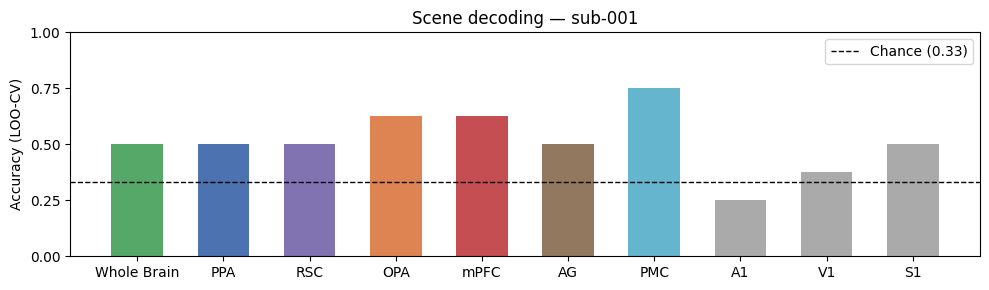

In [18]:
sub1   = tunnel_subjects_filtered[0]
acc    = subject_acc[sub1]
chance = 1 / num_classes

rois   = ["Whole Brain",  "PPA",    "RSC",    "OPA",    "mPFC",    "AG",      "PMC",    "A1",      "V1",      "S1"]
colors = ["#55A868", "#4C72B0", "#8172B2", "#DD8452", "#C44E52", "#937860", "#64B5CD", "#aaaaaa", "#aaaaaa", "#aaaaaa"]
values = [acc[r] for r in rois]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(rois, values, color=colors, width=0.6)
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Scene decoding — {sub1}')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()

Beginning with the single-subject studies, we notice that across the 10 ROIs, most of the regions appear to perform higher than chance, with accuracies of 50% or higher. For instance, the whole brain decoding performance (in green) is close to 50%. This pattern has two exceptions: for A1 and V1, scene decoding performance for `sub-001` is near or below chance, as expected of lower-level sensory processing areas.

Note that LOOCV accuracies with 8 instances can only be multiples of 12.5%. For this reason, many regions appear to have the same accuracy despite the fact that they comprise different voxel groups (50%).

Of the scene-relevant regions, PMC shows the highest decoding accuracy (75%), followed by OPA and mPFC (both 62.5%). S1 also reaches 50% despite serving as a control region. Given the highly quantized nature of LOO-CV with only 8 instances, both the ordering of regions and the S1 result should be interpreted cautiously -- these single-subject findings may not generalize across subjects.

To confirm that the chance level is appropriately placed at 33%, we plot ROI accuracies against the averaged accuracies of 100 permutation tests. These permutation baselines estimate a "null distribution" where the labels are shuffled and all other classification hyperparameters and steps stay the same:

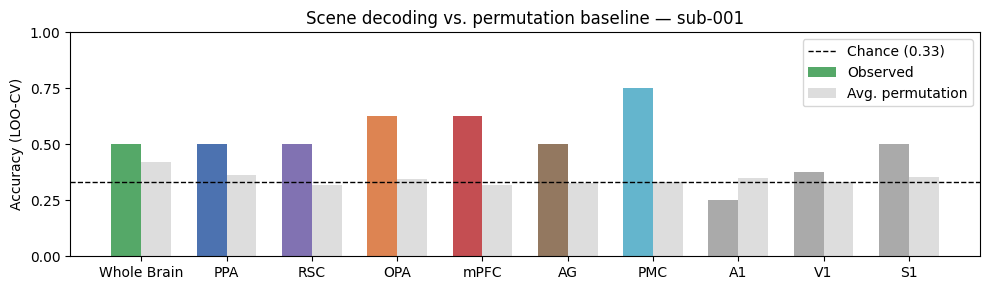

In [19]:
# Per-ROI permutation test for sub-001
rng_perm  = np.random.default_rng(0)
data_sub1 = narratives_utils.load_bold_masked(sub1, "tunnel", mni_mask, standardize=True)

perm_obs      = {}
perm_pval     = {}
perm_null_mean = {}
for roi, roi_mask in roi_masks.items():
    X_roi = build_X(instances, data_sub1[:, roi_mask[mask_data]])
    obs, p, null_mean = evaluate_decoding_perm(X_roi, y, n_perm=100, rng=rng_perm)
    perm_obs[roi]       = obs
    perm_pval[roi]      = p
    perm_null_mean[roi] = null_mean

rois   = ["Whole Brain", "PPA",    "RSC",    "OPA",    "mPFC",    "AG",      "PMC",    "A1",      "V1",      "S1"]
colors = ["#55A868",     "#4C72B0","#8172B2","#DD8452","#C44E52","#937860","#64B5CD","#aaaaaa","#aaaaaa","#aaaaaa"]

x      = np.arange(len(rois))
width  = 0.35
obs_vals  = [perm_obs[r]       for r in rois]
null_vals = [perm_null_mean[r] for r in rois]
pvals     = [perm_pval[r]      for r in rois]

fig, ax = plt.subplots(figsize=(10, 3))
bars_obs  = ax.bar(x - width/2, obs_vals,  width, color=colors,    label='Observed')
bars_null = ax.bar(x + width/2, null_vals, width, color='#dddddd', label='Avg. permutation')
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')

for bar, p in zip(bars_obs, pvals):
    marker = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    if marker:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            marker, ha='center', va='bottom', fontsize=11
        )

ax.set_xticks(x)
ax.set_xticklabels(rois)
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Scene decoding vs. permutation baseline — {sub1}')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()

The averaged permutation accuracies sit at chance level (0.33), confirming that the classifier finds no structure in shuffled labels. The gap between observed and permutation accuracies in scene-relevant regions (PMC, mPFC, OPA) suggests that above-chance performance reflects scene-specific BOLD patterns rather than classifier artifacts.

We perform a similar decoding analysis across all 400 parcels in the Schaefer cortical atlas:

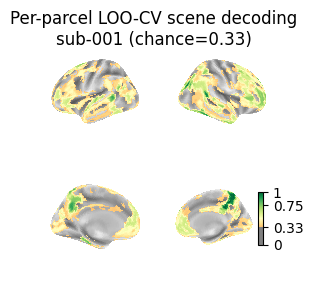

In [20]:
# Subject to plot
surf_sub = tunnel_subjects_filtered[0]
data_sub = narratives_utils.load_bold_masked(surf_sub, "tunnel", mni_mask, standardize=True)

chance = 1 / num_classes
pipe   = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    LinearSVC(max_iter=10000))
])

# Per-parcel LOO-CV
parcel_acc = {}
for parcel_idx in range(1, len(schaefer_labels) + 1):
    parcel_mask = (schaefer_data == parcel_idx) & mask_data
    if parcel_mask.sum() < 5:
        continue
    X_p = build_X(instances, data_sub[:, parcel_mask[mask_data]])
    preds = []
    for i in range(len(X_p)):
        train = [j for j in range(len(X_p)) if j != i]
        pipe.fit(X_p[train], y[train])
        preds.append(pipe.predict(X_p[[i]])[0])
    parcel_acc[parcel_idx] = np.mean(np.array(preds) == y)

best  = max(parcel_acc, key=parcel_acc.get)
worst = min(parcel_acc, key=parcel_acc.get)
if narratives_utils._VERBOSE:
    print(f"Parcels decoded: {len(parcel_acc)}  (chance={chance:.2f})")
    print(f"Best:  {parcel_labels[best]}  acc={parcel_acc[best]:.2f}")
    print(f"Worst: {parcel_labels[worst]}  acc={parcel_acc[worst]:.2f}")

# ── Build result volume ───────────────────────────────────────────────────────
result_vol = np.zeros(schaefer_data.shape)
for idx, acc in parcel_acc.items():
    result_vol[schaefer_data == idx] = acc
result_img = new_img_like(schaefer_img, result_vol)

# ── Surface plot ──────────────────────────────────────────────────────────────
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
fig = plt.figure(figsize=(3, 3))
fig.suptitle(
    f'Per-parcel LOO-CV scene decoding\n{surf_sub} (chance={chance:.2f})',
    fontsize=12
)
for i, (hemi, view) in enumerate([
    ('left',  'lateral'),
    ('right', 'lateral'),
    ('left',  'medial'),
    ('right', 'medial'),
]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'],
        texture,
        hemi=hemi,
        view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='RdYlGn',
        vmax=1.0,
        threshold=chance,
        colorbar=(i == 3),
        symmetric_cbar=False,
        axes=ax,
    )
plt.show()

The surface map shows high decoding accuracy in several expected regions, including the PPA and mPFC, consistent with our hypotheses.

Poor performance in Heschl's gyrus (A1) and striate cortex (V1) mirrors the bar chart results, suggesting that scene-specific representations may be more prevalent in higher-level cortical regions than in primary sensory areas.

This effect is also visible when decoding within each of the 60 parcel groups:

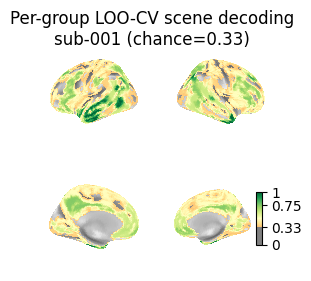

In [21]:
# Per-group LOO-CV for sub-001 (classifier on combined group voxels)
pipe_g = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    LinearSVC(max_iter=10000))
])

group_acc_sub1 = {}
for g, idxs in group_parcel_lists.items():
    vol = np.zeros(schaefer_data.shape, dtype=bool)
    for idx in idxs:
        vol |= (schaefer_data == idx)
    group_mask = (vol & mask_data)[mask_data]
    if group_mask.sum() < 5:
        continue

    # data_sub1 loaded in a previous cell
    X_g = build_X(instances, data_sub1[:, group_mask])
    preds = []
    for i in range(len(X_g)):
        train = [j for j in range(len(X_g)) if j != i]
        pipe_g.fit(X_g[train], y[train])
        preds.append(pipe_g.predict(X_g[[i]])[0])
    group_acc_sub1[g] = np.mean(np.array(preds) == y)

# Build group accuracy volume
group_acc_vol = np.zeros(schaefer_data.shape)
for idx, g in parcel_groups.items():
    if g in group_acc_sub1:
        group_acc_vol[schaefer_data == idx] = group_acc_sub1[g]
group_acc_img = new_img_like(schaefer_img, group_acc_vol)

fig = plt.figure(figsize=(3, 3))
fig.suptitle(
    f'Per-group LOO-CV scene decoding\n{surf_sub} (chance={chance:.2f})',
    fontsize=12
)
for i, (hemi, view) in enumerate([
    ('left',  'lateral'),
    ('right', 'lateral'),
    ('left',  'medial'),
    ('right', 'medial'),
]):
    texture = surface.vol_to_surf(group_acc_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'],
        texture,
        hemi=hemi,
        view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='RdYlGn',
        vmax=1.0,
        threshold=chance,
        colorbar=(i == 3),
        symmetric_cbar=False,
        axes=ax,
    )
plt.show()

The highest-performing groups are concentrated in frontal and temporal cortex, consistent with the per-parcel map, while occipital regions show lower accuracy -- suggesting that scene-specific representations are stronger in higher-level associative areas.

Still, single-subject decoding results should be carefully interpreted, due to the coarse resolution of LOOCV accuracies and potential subject-specific patterns that may not generalize to other populations.

To learn about meaningful connections between brain activity in scene-specific regions and scene decodability, we need to average across more than one subject.

## Averaged Within-Subject Results

Averaging across 20 subjects, scene decoding accuracy is above chance across most of the 10 ROIs, with small standard errors reflecting consistent accuracies across subjects:

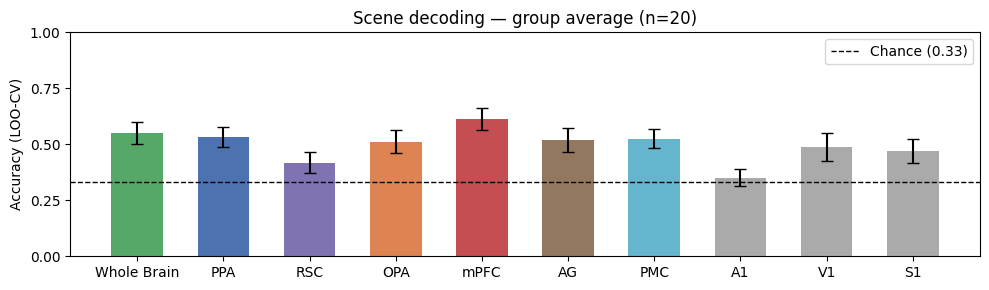

In [22]:
rois   = ["Whole Brain",  "PPA",    "RSC",    "OPA",    "mPFC",    "AG",      "PMC",    "A1",      "V1",      "S1"]
colors = ["#55A868", "#4C72B0", "#8172B2", "#DD8452", "#C44E52", "#937860", "#64B5CD", "#aaaaaa", "#aaaaaa", "#aaaaaa"]

means = [np.mean([v[r] for v in subject_acc.values()]) for r in rois]
sems  = [stats.sem([v[r] for v in subject_acc.values()]) for r in rois]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(
    rois, means,
    yerr=sems, color=colors, width=0.6,
    capsize=4, error_kw=dict(elinewidth=1.5)
)
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Scene decoding — group average (n={len(subject_acc)})')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()

Among the 10 ROIs, mPFC shows the strongest scene decoding accuracy (61.3%), followed by the whole brain (55.0%) and the PPA (53.1%). Due to averaging across multiple subjects, accuracies are no longer evenly spaced at intervals of 12.5%, which makes the results and error bars more reliable.

A1 is the only ROI at chance level, consistent with its role as a low-level auditory control region. Unexpectedly, V1 and S1 also show above-chance accuracies (48.8% and 46.9%, respectively), despite serving as control regions with no theoretical basis for scene decoding in a purely auditory task.

RSC, while part of the canonical place network, shows the weakest performance among scene-relevant regions (~0.40), suggesting it may be less involved in auditory scene reinstatement than visual scene processing.

In [23]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    LinearSVC(max_iter=10000))
])

group_acc_all = {g: [] for g in group_parcel_lists}

for sub in tunnel_subjects_filtered:
    data_sub = narratives_utils.load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    if data_sub is None:
        continue
    for g, idxs in group_parcel_lists.items():
        vol = np.zeros(schaefer_data.shape, dtype=bool)
        for idx in idxs:
            vol |= (schaefer_data == idx)
        group_mask = (vol & mask_data)[mask_data]
        if group_mask.sum() < 5:
            continue
        X_p = build_X(instances, data_sub[:, group_mask])
        preds = []
        for i in range(len(X_p)):
            train = [j for j in range(len(X_p)) if j != i]
            pipe.fit(X_p[train], y[train])
            preds.append(pipe.predict(X_p[[i]])[0])
        group_acc_all[g].append(np.mean(np.array(preds) == y))
    if narratives_utils._VERBOSE:
        print(f"{sub} done")

We extend this analysis to all 60 parcel groups, plotting mean decoding accuracy across subjects before FDR correction:

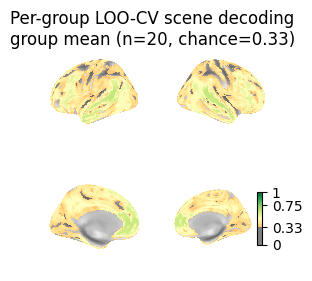

In [24]:
# Mean per-group accuracy across subjects (uses group_acc_all computed earlier)
group_mean_acc = {g: np.mean(accs) for g, accs in group_acc_all.items() if accs}

# Build mean group accuracy volume
group_mean_vol = np.zeros(schaefer_data.shape)
for idx, g in parcel_groups.items():
    if g in group_mean_acc:
        group_mean_vol[schaefer_data == idx] = group_mean_acc[g]
group_mean_img = new_img_like(schaefer_img, group_mean_vol)

fig = plt.figure(figsize=(3, 3))
fig.suptitle(f'Per-group LOO-CV scene decoding\ngroup mean (n={len(tunnel_subjects_filtered)}, chance={chance:.2f})', fontsize=12)
for i, (hemi, view) in enumerate([
    ('left',  'lateral'), ('right', 'lateral'),
    ('left',  'medial'),  ('right', 'medial'),
]):
    texture = surface.vol_to_surf(group_mean_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='RdYlGn', vmax=1.0, threshold=chance,
        colorbar=(i == 3), symmetric_cbar=False, axes=ax,
    )
plt.show()

Most of the cortex shows above-chance decoding, with the strongest performance concentrated in frontal and temporal regions. This broad pattern motivates an FDR correction step, which isolates only the regions with the most robust effects.

Specifically, for the permutation test, we flip the signs of each subject's mean-centered accuracy 100,000 times to simulate a null distribution, then compute p-values as the fraction of flipped means at least as large as the observed mean.

These p-values are then corrected for multiple comparisons across all 60 groups using FDR (false discovery rate correction) at q=0.01, which yields a subset of 18 parcel groups with significantly above-chance decoding accuracy:

In [25]:
N_PERM = 100000
rng = np.random.default_rng(42)

def permutation_test_mean(accs, chance, n_perm=10000):
    """Return the observed mean and p-value for a permutation test.

    Parameters:
    ----------
    accs: list of float
        List of accuracy values.
    chance: float
        Chance level for the test.
    n_perm: int
        Number of permutations to perform.

    Return:
    ------
    obs: float
        Observed mean accuracy.
    p: float
        p-value from the permutation test.
    """
    accs = np.array(accs)
    obs = accs.mean()
    centered = accs - chance
    signs = rng.choice([-1, 1], size=(n_perm, len(accs)))
    null_dist = (signs * centered).mean(axis=1)
    p = (null_dist >= obs - chance).mean()
    return obs, p

group_names, mean_accs, p_vals = [], [], []
for g, accs in group_acc_all.items():
    if len(accs) < 2:
        continue
    mean_acc, p = permutation_test_mean(accs, chance, N_PERM)
    group_names.append(g)
    mean_accs.append(mean_acc)
    p_vals.append(p)

group_names = np.array(group_names)
mean_accs   = np.array(mean_accs)
p_vals      = np.array(p_vals)

reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.01, method='fdr_bh')

if narratives_utils._VERBOSE:
    print(f"{reject.sum()} / {len(reject)} parcel groups significant (FDR q=0.01)\n")

df = pd.DataFrame(columns=[
    "Parcel Group",
    "Mean Accuracy",
    "p-value (FDR)"
])

for group, mean, p_val, reject_null in sorted(zip(group_names, mean_accs, p_fdr, reject), key=lambda x: -x[1]):
    if reject_null:
        df.loc[len(df)] = [group, mean, p_val]

# Display significant results
df

Parcel Group,Mean Accuracy,p-value (FDR)
TempPar,0.643750,0.000000
DefaultA_PFCm,0.637500,0.000200
DefaultB_Temp,0.618750,0.000257
DefaultB_IPL,0.593750,0.000450
DefaultB_PFCd,0.593750,0.000150
DefaultB_PFCv,0.581250,0.000200
ContA_PFCl,0.568750,0.000150
ContB_PFClv,0.543750,0.000150
DefaultC_PHC,0.531250,0.001440
DorsAttnA_ParOcc,0.525000,0.000467


The significant groups are heavily concentrated in the default mode network (DefaultA, DefaultB, DefaultC prefixes) and control network (ContA, ContB), with the strongest effect in TempPar (64.4%) and DefaultA_PFCm (63.8%) -- both overlapping with the mPFC region that led the ROI analysis. Notably, DefaultC_PHC (53.1%) corresponds to the PPA, consistent with our hypothesis. The two DorsAttn groups suggest some involvement of dorsal attention regions, while VisPeri_ExStrSup is the only visual region to survive correction, which may relate to the unexpected V1 finding in the 10 ROI analysis.

Below is a brain map of the decoding accuracies of all 18 parcel groups that survive FDR:

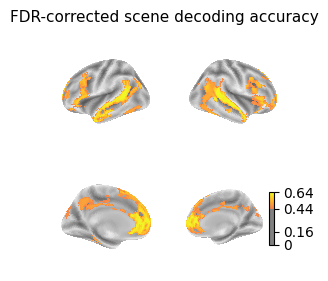

In [26]:
result_vol = np.full(schaefer_data.shape, np.nan)
for g, acc, r in zip(group_names, mean_accs, reject):
    if not r:
        continue
    for idx, grp in parcel_groups.items():
        if grp == g:
            result_vol[schaefer_data == idx] = acc

result_img = new_img_like(schaefer_img, np.where(np.isnan(result_vol), 0, result_vol))

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
acc_min = mean_accs[reject].min() if reject.any() else 0.0

fig = plt.figure(figsize=(3, 3))
fig.suptitle('FDR-corrected scene decoding accuracy', fontsize=11)
for i, (hemi, view) in enumerate([('left','lateral'), ('right','lateral'),
                                    ('left','medial'),  ('right','medial')]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='plasma', threshold=acc_min,
        colorbar=(i == 3), symmetric_cbar=False, axes=ax,
    )
plt.show()

Just as in the single-subject case, significant parcel groups appear to be concentrated in frontal and temporal cortex (particularly along the default mode network), with the strongest decoding in prefrontal and temporoparietal regions. The medial surface shows additional significant clusters in posterior cingulate and precuneus areas, alongside the PPA. Primary sensory cortex is largely absent, consistent with the ROI-level finding that scene-specific representations are strongest in higher-level associative regions.

## Scene-Level RSA Results

Below are the scene-level RSA plots (averaged across subjects and blocked by scene) for the PPA and mPFC ROIs:

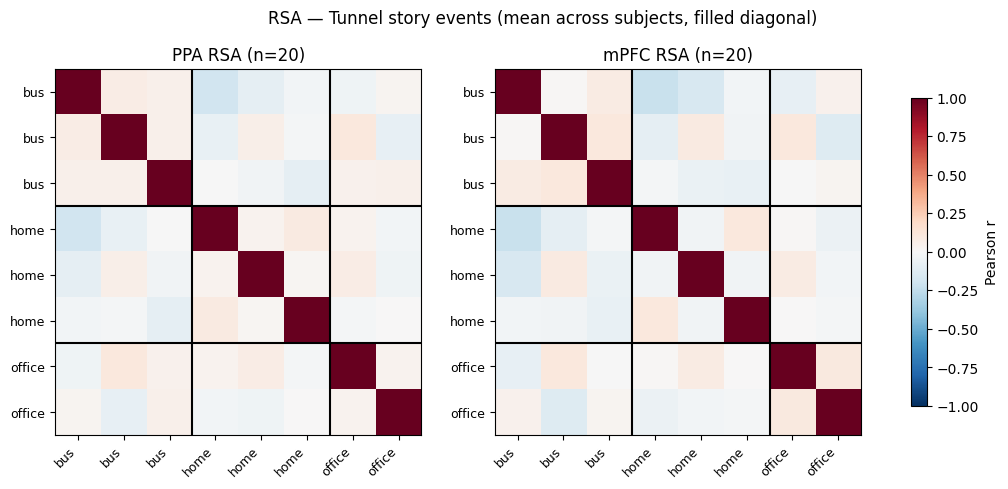

In [27]:
# Collect per-subject RSA matrices — PPA and mPFC
rsa_ppa_list  = []
rsa_mpfc_list = []

ppa_voxels  = roi_masks["PPA"][mask_data]
mpfc_voxels = roi_masks["mPFC"][mask_data]

for sub_i in tunnel_subjects_filtered:
    data_i = narratives_utils.load_bold_masked(sub_i, 'tunnel', mni_mask, standardize=True)
    if data_i is None:
        continue
    X_ppa  = build_X(instances, data_i[:, ppa_voxels])
    X_mpfc = build_X(instances, data_i[:, mpfc_voxels])
    rsa_ppa_list.append(np.corrcoef(X_ppa))
    rsa_mpfc_list.append(np.corrcoef(X_mpfc))

mean_ppa  = np.mean(rsa_ppa_list,  axis=0)
mean_mpfc = np.mean(rsa_mpfc_list, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_rsa(axes[0], mean_ppa,  f'PPA RSA (n={len(rsa_ppa_list)})')
img = plot_rsa(axes[1], mean_mpfc, f'mPFC RSA (n={len(rsa_mpfc_list)})')
fig.colorbar(img, ax=axes, label='Pearson r', shrink=0.8)
plt.suptitle('RSA — Tunnel story events (mean across subjects, filled diagonal)', fontsize=12)
plt.show()

Both regions show a clear block structure, with within-scene pairs (e.g., bus-bus, home-home) showing higher correlation than cross-scene pairs. The PPA shows stronger within-scene similarity in the bus and home blocks. Meanwhile, the mPFC shows a more mixed pattern, with positive within-scene correlations for bus and office but notably negative correlations within the home block.

Cross-scene correlations are generally near zero or slightly negative, suggesting that the BOLD patterns for different scenes are not only distinct but partially decorrelated -- this is consistent with the high decoding accuracies observed in both regions.

To focus on non-diagonal entries of the RSA plot, we create another version with the diagonal removed:

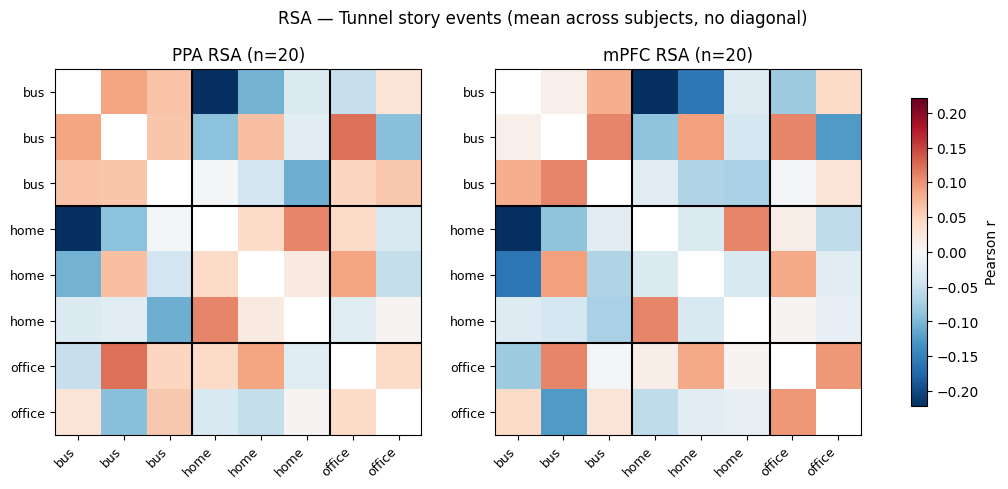

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_rsa(axes[0], mean_ppa,  f'PPA RSA (n={len(rsa_ppa_list)})', exclude_diagonal=True)
img = plot_rsa(axes[1], mean_mpfc, f'mPFC RSA (n={len(rsa_mpfc_list)})', exclude_diagonal=True)
fig.colorbar(
    img,
    ax=axes,
    label='Pearson r',
    shrink=0.8
)
plt.suptitle('RSA — Tunnel story events (mean across subjects, no diagonal)', fontsize=12)
plt.show()

Without the diagonal, the within-scene block structure is less pronounced than the filled-diagonal version suggested, indicating that much of the apparent scene similarity was driven by self-correlations. Nevertheless, the PPA shows more consistent within-scene positive correlations (orange) compared to the mPFC. For cross-scene correlations, mPFC negative correlations are more pronounced, suggesting that the mPFC play more of a role in actively discriminating between scenes.

# Discussion

## Support for Hypothesis

Our results show that scene identity during a purely auditory narrative can be reliably decoded from fMRI activity from the same subject, with performance concentrated in higher-level cortical regions rather than primary sensory areas. Across 20 subjects, the mPFC showed the strongest average decoding accuracy (61%), followed by the whole brain (55%) and PPA (53%), while 18 of 60 Schaefer parcel groups survived FDR correction at q=0.01, concentrated in the default mode and control networks.

Unlike prior work on audiovisual stimuli (<u>Milivojevic et al., 2016</u>), our results show that scene-specific representations persist even without visual input. To our knowledge, this is the first demonstration that recurring scene identity in a naturalistic auditory narrative can be decoded from brain activity.

The PPA result is consistent with prior work showing that place-related imagery and language reliably engage this region even in the absence of visual input. <u>O'Craven and Kanwisher (2000)</u> showed that mental imagery of places activates the PPA similarly to visual perception, and <u>Aziz et al. (2008)</u> found that reading language about places modulates PPA activity. Our finding extends this to a naturalistic listening context, suggesting that as subjects encounter familiar scene onsets in the narrative, language-driven imagery is sufficient to reinstate scene-specific representations in the PPA. This interpretation is also supported by <u>Hausler et al. (2022)</u>, who showed that the PPA processes non-visual spatial information more broadly.

The mPFC's leading role in scene decoding connects naturally to the literature of event models. <u>Baldassano et al. (2017, 2018)</u> showed that the DMN, including the mPFC, tracks event structure during narrative comprehension, with activity patterns shifting at event boundaries. Our results suggest the mPFC does not merely detect transitions between events, but also maintains scene-specific representations that remain consistent across multiple instances of the same scene -- even when those instances are separated by many minutes of intervening scenes.

The RSA analysis adds further context: while the PPA shows more consistent within-scene positive correlations, the mPFC shows stronger cross-scene negative correlations, suggesting a complementary functional division where the PPA contributes to scene reinstatement and the mPFC to scene discrimination.

## Unexpected Findings

Two findings deviate from our predictions and deserve comment.

First, V1 and S1 show small but consistent above-chance decoding (49% and 47%, respectively) across subjects, despite no theoretical basis for scene-specific representations in primary sensory cortex during an auditory task. One possible explanation is that each scene onset contains shared low-level acoustic features -- for instance, voices or rhythmic patterns in the narration -- that are partially decodable from early sensory regions. Alternatively, the V1 result could reflect top-down visual imagery, consistent with the known role of V1 in visual mental imagery (<u>Pearson, 2019</u>). Our S1 result before FDR remains unexplained, and it would be reasonable to replicate this experiment at a larger scale to determine if somatosensory areas would still have above-chance decoding performance. Notably, both V1 and S1 effects did not survive FDR correction, suggesting limited robustness in our dataset.

Second, RSC shows the weakest performance among scene-relevant regions (~40%), which is somewhat surprising given its inclusion in the place network. RSC may be more involved in spatial navigation and visual scene recognition than in the kind of narrative-based scene reinstatement studied here.

## Conclusion

Several limitations of this study should be noted. We only have 8 scene instances, with a slight class imbalance (3 home, 3 bus, 2 office), which limits statistical power and makes the office class harder to decode. All analyses are restricted to a single story, so it is unclear whether these results would generalize to other narratives or other types of recurring scenes. We also use a fixed HRF lag of 6 seconds for all subjects and regions, whereas hemodynamic response timing may vary across individuals and cortical areas.

Taken together, our findings suggest that scene-relevant brain regions -- originally characterized through visual and audiovisual paradigms -- have a more general role in maintaining mental context during language comprehension. The mPFC and PPA appear to encode scene-specific representations that persist across narrative instances, supporting the idea that scene reinstatement from language alone may be a core function of the place and default mode networks during story listening.

# Negative Results

In this section, we present negative results for two extensions of our work with the Narratives dataset, and then explain why scene decoding may be difficult for those cases.

## Cross-Subject Decoding

One way to extend our results would be to fit a Shared Response Model (SRM) on other stories that most `tunnel` subjects listened to (`pieman` and `lucy`), then use the shared space to train decoding on some subjects and test on held-out ones.

Before doing that, we can test if cross-subject decoding without SRM is possible. We use a nested approach, where we leave out one subject-scene pair (which we nickname LOSSO for short), and train on all other instances from all other subjects. Our results when training on the PPA are quite poor:

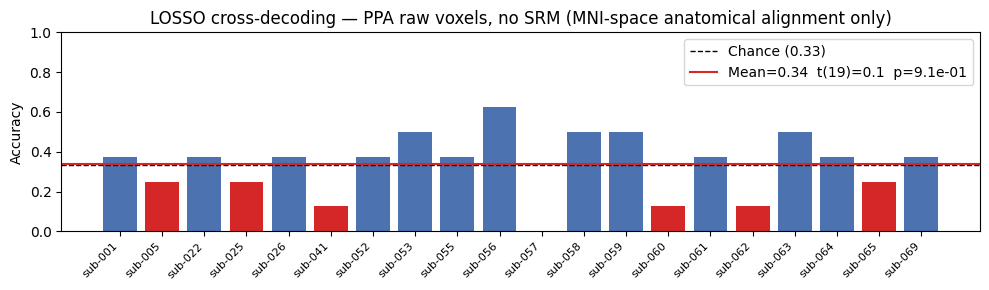

In [29]:
# ATTRIBUTION: This code was written by Claude and checked by me.

# Direct anatomical cross-subject decoding (no SRM)
# Data is already in MNI space, so anatomical alignment is free.
# LOSSO: train on all but one subject-scene pair, test on held-out.

losso_raw_acc = {}
raw_subs = [s for s in tunnel_subjects_filtered
            if narratives_utils.load_bold_masked(s, "tunnel", mni_mask, standardize=True) is not None]

X_ppa_raw = {}
for sub in raw_subs:
    data = narratives_utils.load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    X_ppa_raw[sub] = build_X(instances, data[:, roi_masks["PPA"][mask_data]])

for test_sub in raw_subs:
    train_subs = [s for s in raw_subs if s != test_sub]
    preds = []
    for i in range(len(instances)):
        keep    = [j for j in range(len(instances)) if j != i]
        X_train = np.vstack([X_ppa_raw[s][keep] for s in train_subs])
        y_train = np.tile(y[keep], len(train_subs))
        pipe    = Pipeline([
            ("scaler", StandardScaler()),
            ("svm",    LinearSVC(max_iter=10000))
        ])
        pipe.fit(X_train, y_train)
        preds.append(pipe.predict(X_ppa_raw[test_sub][[i]])[0])
    losso_raw_acc[test_sub] = np.mean(np.array(preds) == y)
    if narratives_utils._VERBOSE:
        print(f"{test_sub}  acc={losso_raw_acc[test_sub]:.3f}")

accs_raw          = list(losso_raw_acc.values())
t_stat_r, p_t_r   = stats.ttest_1samp(accs_raw, 1/3)
w_stat_r, p_wil_r = stats.wilcoxon(accs_raw, [1/3] * len(accs_raw), alternative="greater")

if narratives_utils._VERBOSE:
    print(f"Mean LOSSO-raw-PPA acc = {np.mean(accs_raw):.3f} +/- {stats.sem(accs_raw):.3f}")
    print(f"t({len(accs_raw)-1}) = {t_stat_r:.3f},  p = {p_t_r:.2e}  (vs chance = 0.33)")

fig, ax = plt.subplots(figsize=(10, 3))
colors_bar = ["#d62728" if a <= 1/3 else "#4C72B0" for a in accs_raw]
ax.bar(raw_subs, accs_raw, color=colors_bar)
ax.axhline(
    1/3,
    color="k", linestyle="--", linewidth=1,
    label="Chance (0.33)"
)
ax.axhline(
    np.mean(accs_raw),
    color="#d62728", linestyle="-", linewidth=1.5,
    label=f"Mean={np.mean(accs_raw):.2f}  t({len(accs_raw)-1})={t_stat_r:.1f}  p={p_t_r:.1e}"
)
ax.set_xticks(range(len(raw_subs)))
ax.set_xticklabels(raw_subs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_title("LOSSO cross-decoding — PPA raw voxels, no SRM (MNI-space anatomical alignment only)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

To rule out poor alignment between specific voxels in patients' PPA regions, we also test PPA-specific SRM fit on two other stories (reducing the number of available subjects, since not all listened to `pieman` and `lucy`):

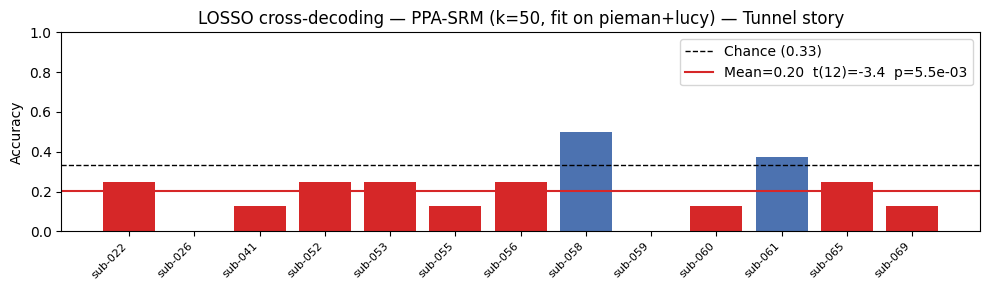

In [30]:
# ATTRIBUTION: This code was written by Claude and checked by me.

# ── PPA-restricted SRM + LOSSO ────────────────────────────────────────────────
# Fit SRM only on PPA voxels — smaller, better-determined shared space.
# ppa_vox: boolean index into the MNI-masked voxel vector (length = n_voxels).

from brainiak.funcalign.srm import SRM

SRM_K_PPA    = 50
SRM_ITER_PPA = 20
SRM_TASKS    = ["pieman", "lucy"]
_CACHE_DIR   = Path("/scratch/network/ih2422/narratives_cache")
_tasks_tag   = "+".join(SRM_TASKS)

ppa_vox = roi_masks["PPA"][mask_data]
if narratives_utils._VERBOSE:
    print(f"PPA voxels: {ppa_vox.sum()}")

srm_ppa_cache = _CACHE_DIR / f"srm_ppa_k{SRM_K_PPA}_iter{SRM_ITER_PPA}_{_tasks_tag}.npz"

srm_ppa_subs = [s for s in tunnel_subjects_filtered
                if all(narratives_utils.load_bold_masked(s, t, mni_mask) is not None for t in SRM_TASKS)]

if srm_ppa_cache.exists():
    if narratives_utils._VERBOSE:
        print(f"[cache] loading PPA-SRM from {srm_ppa_cache.name}")
    saved_ppa  = np.load(srm_ppa_cache)
    W_ppa_list = [saved_ppa[sub] for sub in srm_ppa_subs]
else:
    srm_ppa_arrays = []
    for sub in srm_ppa_subs:
        runs   = [narratives_utils.load_bold_masked(sub, t, mni_mask, standardize=True) for t in SRM_TASKS]
        concat = np.concatenate(runs, axis=0)         # (TRs, n_voxels)
        srm_ppa_arrays.append(concat[:, ppa_vox].T)   # (n_ppa_voxels, TRs)
    min_trs        = min(a.shape[1] for a in srm_ppa_arrays)
    srm_ppa_arrays = [a[:, :min_trs] for a in srm_ppa_arrays]
    srm_ppa        = SRM(n_iter=SRM_ITER_PPA, features=SRM_K_PPA)
    srm_ppa.fit(srm_ppa_arrays)
    W_ppa_list = srm_ppa.w_
    np.savez(srm_ppa_cache, **{sub: W for sub, W in zip(srm_ppa_subs, W_ppa_list)})
    if narratives_utils._VERBOSE:
        print(f"[cache] saved PPA-SRM to {srm_ppa_cache.name}")

if narratives_utils._VERBOSE:
    print(f"PPA-SRM ready: k={SRM_K_PPA}, {len(srm_ppa_subs)} subjects, fit on {_tasks_tag}")

# ── Project tunnel instance patterns (PPA voxels only) into shared space ──────
X_ppa_shared = {}
for i, sub in enumerate(srm_ppa_subs):
    data              = narratives_utils.load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    X_i               = build_X(instances, data[:, ppa_vox])  # (n_instances, n_ppa_voxels)
    X_ppa_shared[sub] = X_i @ W_ppa_list[i]                   # (n_instances, SRM_K_PPA)

# ── LOSSO cross-decoding ──────────────────────────────────────────────────────
losso_ppa_acc = {}
for test_sub in srm_ppa_subs:
    train_subs = [s for s in srm_ppa_subs if s != test_sub]
    preds = []
    for i in range(len(instances)):
        keep    = [j for j in range(len(instances)) if j != i]
        X_train = np.vstack([X_ppa_shared[s][keep] for s in train_subs])
        y_train = np.tile(y[keep], len(train_subs))
        pipe    = Pipeline([
            ("scaler", StandardScaler()),
            ("svm",    LinearSVC(max_iter=10000))
        ])
        pipe.fit(X_train, y_train)
        preds.append(pipe.predict(X_ppa_shared[test_sub][[i]])[0])
    losso_ppa_acc[test_sub] = np.mean(np.array(preds) == y)
    if narratives_utils._VERBOSE:
        print(f"{test_sub}  acc={losso_ppa_acc[test_sub]:.3f}")

accs_ppa          = list(losso_ppa_acc.values())
t_stat_p, p_t_p   = stats.ttest_1samp(accs_ppa, 1/3)
w_stat_p, p_wil_p = stats.wilcoxon(accs_ppa, [1/3] * len(accs_ppa), alternative="greater")

if narratives_utils._VERBOSE:
    print(f"Mean LOSSO-PPA acc = {np.mean(accs_ppa):.3f} +/- {stats.sem(accs_ppa):.3f}")
    print(f"t({len(accs_ppa)-1}) = {t_stat_p:.3f},  p = {p_t_p:.2e}  (vs chance = 0.33)")

fig, ax = plt.subplots(figsize=(10, 3))
colors_bar = ["#d62728" if a <= 1/3 else "#4C72B0" for a in accs_ppa]
ax.bar(srm_ppa_subs, accs_ppa, color=colors_bar)
ax.axhline(1/3, color="k", linestyle="--", linewidth=1, label="Chance (0.33)")
ax.axhline(
    np.mean(accs_ppa),
    color="#d62728", linestyle="-", linewidth=1.5,
    label=f"Mean={np.mean(accs_ppa):.2f}  t({len(accs_ppa)-1})={t_stat_p:.1f}  p={p_t_p:.1e}"
)
ax.set_xticks(range(len(srm_ppa_subs)))
ax.set_xticklabels(srm_ppa_subs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Accuracy")
ax.set_title(
    f"LOSSO cross-decoding — PPA-SRM (k={SRM_K_PPA}, fit on {_tasks_tag}) — Tunnel story"
)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

Interpreting our results, the cross-subject decoding on raw PPA voxels results in a mean accuracy of 34% -- basically chance (p=0.91 for a t-test). This suggests that PPA scene representations are not sufficiently consistent across individuals (at the voxel level) for a classifier trained on one subject's data to generalize to another's, even in MNI space.

Applying SRM (k=50, fit on `pieman` and `lucy`) to project each subject's PPA activity into a common functional space made performance significantly worse rather than better: mean accuracy dropped to 20%, significantly below chance (t(12)=−3.4, p=0.005). The SRM shared space, learned from two unrelated stories, appears to capture inter-subject patterns that are unrelated to scene identity in `tunnel`. The loss of 7 subjects (those without `pieman` and `lucy` data) further reduces the training set. Together, these results suggest that scene-specific representations in PPA are inconsistent across individuals enough that neither anatomical nor shared response alignment is sufficient for cross-subject generalization with this dataset and sample size.

## Other Narratives

Another natural extension of our results would be to perform scene decoding in another story, which also has a repeated structure of visiting the same scenes. One candidate story is `21styear`, which we abbreviate to `twenty` in our code. We perform the same steps of subject filtering and computing scene onsets, but there is one key difference: the two scenes being distinguished are both **homes** (the same type of scene) -- Clara's home and Steven's home.

25 twenty subjects: ['sub-075', 'sub-131', 'sub-190', 'sub-201', 'sub-235', 'sub-244', 'sub-249', 'sub-254', 'sub-255', 'sub-256', 'sub-257', 'sub-258', 'sub-259', 'sub-260', 'sub-261', 'sub-262', 'sub-263', 'sub-264', 'sub-265', 'sub-266', 'sub-267', 'sub-268', 'sub-269', 'sub-270', 'sub-271']


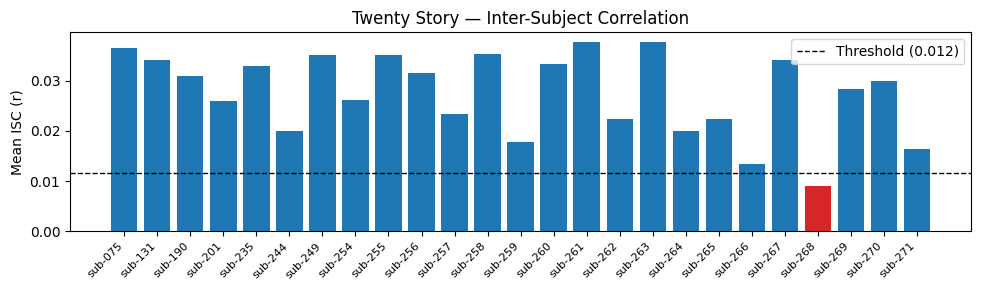

In [31]:
twenty_segments = narratives_utils.fetch_segments("21styear")
twenty_subjects = narratives_utils.fetch_subject_list("21styear")
print(f"{len(twenty_subjects)} twenty subjects: {twenty_subjects}")

# ISC-based attention filter (based on the ISC approach described in Hasson et al., 2004)
_mni = datasets.load_mni152_brain_mask(resolution=4)
twenty_isc_scores, twenty_subjects_filtered = narratives_utils.isc_filter(
    twenty_subjects,
    "21styear",
    _mni,
    title="Twenty Story — Inter-Subject Correlation"
)

In [32]:
# Fetch the transcript from whisperx
twenty_whisperx_transcript = narratives_utils.fetch_whisperx_transcript("21styear")

# Print the beginning of the story
print(twenty_whisperx_transcript[:100] + "...")

This is Los Angeles and it's the height of summer. In a small bungalow off La Cienega, Clara serves ...


In [33]:
# Fetch the segments for the twenty story, from the .tsv file from the previous cell
twenty_segments = narratives_utils.fetch_segments("21styear")

# Align the annotated scenes to the segments, using the whisperx transcript
twenty_aligned = narratives_utils.align_tsv_to_whisperx(
    Path("twenty_scenes.tsv"),
    twenty_segments,
    narratives_utils.fetch_whisperx_transcript("21styear")
)

In [34]:
# Colors for the timeline plot
twenty_colors = {
    "clara_home": "#B04C4C",
    "steven_home": "#00BFFF",
    "other": "#bbbbbb"
}

# Labeled scene names
twenty_labeled_scenes = ["clara_home", "steven_home"]

# Instances (ignoring "other" scenes)
twenty_instances = [row for row in twenty_aligned if row["scene"] in twenty_labeled_scenes]

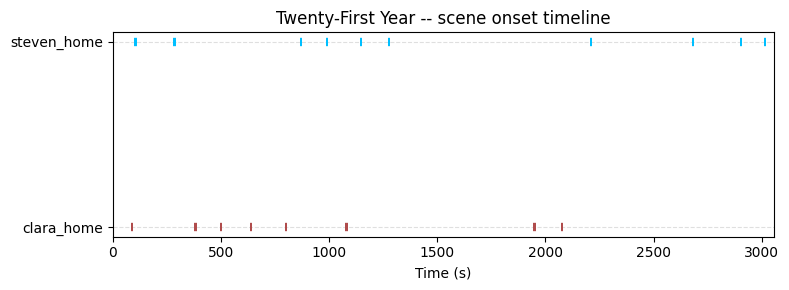

In [35]:
# Plot instance onsets for the tunnel story
narratives_utils.plot_instance_onsets(
    twenty_instances,
    "Twenty-First Year -- scene onset timeline",
    twenty_labeled_scenes,
    twenty_colors
)

In [36]:
# Encode labels once — same for every subject
twenty_y = LabelEncoder().fit_transform([instance["scene"] for instance in twenty_instances])
num_classes = np.unique(twenty_y).size

In [37]:
subject_acc = {}

for sub_i in twenty_subjects_filtered:
    data_i = narratives_utils.load_bold_masked(sub_i, "21styear", mni_mask, standardize=True)
    if data_i is None:
        print(f"{sub_i}  — file missing, skipping")
        continue

    stimulus_duration = data_i.shape[0] * TR

    # ROI accuracies (no feature selection — ROIs already small)
    roi_accs = {}
    for roi, roi_mask in roi_masks.items():
        roi_data_i = data_i[:, roi_mask[mask_data]]
        roi_accs[roi] = evaluate_decoding(build_X(twenty_instances, roi_data_i), twenty_y)

    subject_acc[sub_i] = roi_accs
    if narratives_utils._VERBOSE:
        print(
            f"{sub_i}  dur={stimulus_duration:.1f}s"
            f"  whole-brain={roi_accs['Whole Brain']:.2f}"
            f"  PPA={roi_accs['PPA']:.2f}  RSC={roi_accs['RSC']:.2f}"
            f"  OPA={roi_accs['OPA']:.2f}  mPFC={roi_accs['mPFC']:.2f}"
            f"  AG={roi_accs['AG']:.2f}  PMC={roi_accs['PMC']:.2f}"
            f"  A1={roi_accs['A1']:.2f}  V1={roi_accs['V1']:.2f}  S1={roi_accs['S1']:.2f}"
        )

chance = 1 / num_classes

mean_wb   = np.mean([v["Whole Brain"]   for v in subject_acc.values()])
mean_ppa  = np.mean([v["PPA"]  for v in subject_acc.values()])
mean_rsc  = np.mean([v["RSC"]  for v in subject_acc.values()])
mean_opa  = np.mean([v["OPA"]  for v in subject_acc.values()])
mean_mpfc = np.mean([v["mPFC"] for v in subject_acc.values()])
mean_ag   = np.mean([v["AG"]   for v in subject_acc.values()])
mean_pmc  = np.mean([v["PMC"]  for v in subject_acc.values()])
mean_a1   = np.mean([v["A1"]   for v in subject_acc.values()])
mean_v1   = np.mean([v["V1"]   for v in subject_acc.values()])
mean_s1   = np.mean([v["S1"]   for v in subject_acc.values()])

if narratives_utils._VERBOSE:
    print(
        f"\nMean  whole-brain={mean_wb:.2f}"
        f"  PPA={mean_ppa:.2f}  RSC={mean_rsc:.2f}  OPA={mean_opa:.2f}"
        f"  mPFC={mean_mpfc:.2f}  AG={mean_ag:.2f}  PMC={mean_pmc:.2f}"
        f"  A1={mean_a1:.2f}  V1={mean_v1:.2f}  S1={mean_s1:.2f}"
        f"  (chance={chance:.2f})"
    )
    print(f"Above chance (wb): {sum(v['Whole Brain'] > chance for v in subject_acc.values())}/{len(subject_acc)} subjects")

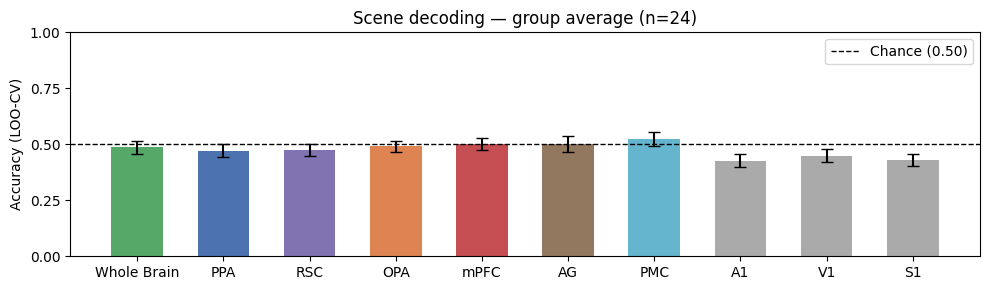

In [38]:
rois   = ["Whole Brain",  "PPA",    "RSC",    "OPA",    "mPFC",    "AG",      "PMC",    "A1",      "V1",      "S1"]
colors = ["#55A868", "#4C72B0", "#8172B2", "#DD8452", "#C44E52", "#937860", "#64B5CD", "#aaaaaa", "#aaaaaa", "#aaaaaa"]

means = [np.mean([v[r] for v in subject_acc.values()]) for r in rois]
sems  = [stats.sem([v[r] for v in subject_acc.values()]) for r in rois]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(
    rois, means,
    yerr=sems, color=colors, width=0.6,
    capsize=4, error_kw=dict(elinewidth=1.5)
)
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Scene decoding — group average (n={len(subject_acc)})')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()

Unlike the Tunnel results, scene decoding in `21styear` is consistently at or below chance across all 10 ROIs. These results are very different from the `tunnel` story, despite using the same pipeline, the same subjects, and the same decoding approach.

The most natural explanation is that the two scenes being decoded -- Clara's home and Steven's home -- belong to the same scene category. The place network and default mode network regions that drove `tunnel` decoding are sensitive to the type of spatial environment (home, bus, office), not to which specific instance of that environment is being visited. Both homes in 21styear recruit the same underlying spatial schema and place models, leaving no categorical signal for the classifier to separate. Distinguishing Clara's home from Steven's requires tracking character identity and narrative context rather than scene type -- a different cognitive process that may not be localized to the regions we examined. This null result therefore clarifies what `tunnel` was actually measuring: not just any repeated narrative structure, but distinct spatial environments that elicit different, decodable scene representations.

# References

**Note:** I used Google Scholar to copy the BibTeX citations for each source, which I list below:

**Aziz et al., 2008**
* @article{aziz2008modulation,
    title={Modulation of the FFA and PPA by language related to faces and places},
    author={Aziz-Zadeh, Lisa and Fiebach, Christian J and Naranayan, Srini and Feldman, Jerome and Dodge, Ellen and Ivry, Richard B},
    journal={Social Neuroscience},
    volume={3},
    number={3-4},
    pages={229--238},
    year={2008},
    publisher={Taylor \& Francis}
  }

**Baldassano et al., 2017**
* @article{baldassano2017discovering,
    title={Discovering event structure in continuous narrative perception and memory},
    author={Baldassano, Christopher and Chen, Janice and Zadbood, Asieh and Pillow, Jonathan W and Hasson, Uri and Norman, Kenneth A},
    journal={Neuron},
    volume={95},
    number={3},
    pages={709--721},
    year={2017},
    publisher={Elsevier}
  }

**Baldassano et al., 2018**
* @article{baldassano2018representation,
    title={Representation of real-world event schemas during narrative perception},
    author={Baldassano, Christopher and Hasson, Uri and Norman, Kenneth A},
    journal={Journal of Neuroscience},
    volume={38},
    number={45},
    pages={9689--9699},
    year={2018},
    publisher={Society for Neuroscience}
  }

**Hasson et al., 2004**
* @article{hasson2004intersubject,
    title={Intersubject synchronization of cortical activity during natural vision},
    author={Hasson, Uri and Nir, Yuval and Levy, Ifat and Fuhrmann, Galit and Malach, Rafael},
    journal={science},
    volume={303},
    number={5664},
    pages={1634--1640},
    year={2004},
    publisher={American Association for the Advancement of Science}
  }

**Hausler et al., 2022**
* @article{hausler2022processing,
    title={Processing of visual and non-visual naturalistic spatial information in the" parahippocampal place area"},
    author={H{\"a}usler, Christian O and Eickhoff, Simon B and Hanke, Michael},
    journal={Scientific data},
    volume={9},
    number={1},
    pages={147},
    year={2022},
    publisher={Nature Publishing Group UK London}
  }

**Lerner at al., 2011**
* @article{lerner2011topographic,
    title={Topographic mapping of a hierarchy of temporal receptive windows using a narrated story},
    author={Lerner, Yulia and Honey, Christopher J and Silbert, Lauren J and Hasson, Uri},
    journal={Journal of neuroscience},
    volume={31},
    number={8},
    pages={2906--2915},
    year={2011},
    publisher={Society for Neuroscience}
  }

**Lositsky et al., 2016**
* @article{
    lositsky2016neural,
    title={Neural pattern change during encoding of a narrative predicts retrospective duration estimates},
    author={Lositsky, Olga and Chen, Janice and Toker, Daniel and Honey, Christopher J and Shvartsman, Michael and Poppenk, Jordan L and Hasson, Uri and Norman, Kenneth A},
    journal={elife},
    volume={5},
    pages={e16070},
    year={2016},
    publisher={eLife Sciences Publications, Ltd}
  }

**Milovojevic et al., 2016**
* @article{milivojevic2016coding,
    title={Coding of event nodes and narrative context in the hippocampus},
    author={Milivojevic, Branka and Varadinov, Meryl and Vicente Grabovetsky, Alejandro and Collin, Silvy HP and Doeller, Christian F},
    journal={The Journal of Neuroscience},
    volume={36},
    number={49},
    pages={12412--12424},
    year={2016},
    publisher={Society for Neuroscience}
}

**Nastase et al., 2019:**
* @misc{nastase2019measuring,
    title={Measuring shared responses across subjects using intersubject correlation},
    author={Nastase, Samuel A and Gazzola, Valeria and Hasson, Uri and Keysers, Christian},
    journal={Social cognitive and affective neuroscience},
    volume={14},
    number={6},
    pages={667--685},
    year={2019},
    publisher={Oxford University Press}
  }

**Nastase et al., 2021:**
* @article{
    nastase2021narratives,
    title={The “Narratives” fMRI dataset for evaluating models of naturalistic language comprehension},
    author={Nastase, Samuel A and Liu, Yun-Fei and Hillman, Hanna and Zadbood, Asieh and Hasenfratz, Liat and Keshavarzian, Neggin and Chen, Janice and Honey, Christopher J and Yeshurun, Yaara and Regev, Mor and others},
    journal={Scientific data},
    volume={8},
    number={1},
    pages={250},
    year={2021},
    publisher={Nature Publishing Group UK London}
  }

**O'Craven et al., 2000**
* @article{o2000mental,
    title={Mental imagery of faces and places activates corresponding stimulus-specific brain regions},
    author={O'Craven, Kathleen M and Kanwisher, Nancy},
    journal={Journal of cognitive neuroscience},
    volume={12},
    number={6},
    pages={1013--1023},
    year={2000},
    publisher={MIT Press One Rogers Street, Cambridge, MA 02142-1209, USA journals-info~…}
  }

**Pearson, 2019**
* @article{pearson2019human,
    title={The human imagination: the cognitive neuroscience of visual mental imagery},
    author={Pearson, Joel},
    journal={Nature reviews neuroscience},
    volume={20},
    number={10},
    pages={624--634},
    year={2019},
    publisher={Nature Publishing Group UK London}
  }

**Schaefer et al., 2018**
* @article{schaefer2018local,
    title={Local-global parcellation of the human cerebral cortex from intrinsic functional connectivity MRI},
    author={Schaefer, Alexander and Kong, Ru and Gordon, Evan M and Laumann, Timothy O and Zuo, Xi-Nian and Holmes, Avram J and Eickhoff, Simon B and Yeo, BT Thomas},
    journal={Cerebral cortex},
    volume={28},
    number={9},
    pages={3095--3114},
    year={2018},
    publisher={Oxford University Press}
  }

# AI Appendix

For my project, all of the code for the main figures in the Methods and Results sections were created by me. AI models did not write the decoding or graphing code directly; although I sometimes implemented suggestions from AI, I am responsible for fMRI processing and figure formatting code in the Methods and Results sections of this report. I relied more heavily on Claude Code for the optional Negative Results section on Cross-Subject Decoding.

I did use an AI agent (Claude Code) as a post-processing helper for my notebook. In particular, I used Claude Code for five main purposes:
1. Cleaning up formatting, since my code structure was somewhat inconsistent across cells. Since LLMs are reasonably good at reformatting existing code, I used Claude Code to reformat my code, using tabs appropriately, splitting lines of code that were too long, and improving docstring consistency. This bullet point applies both to this notebook (main.ipynb) but also the narratives_utils Python file.
2. As a "peer reviewer" for my code implementation - every time I completed a code cell, I would ask Claude Code to review the cell, to check if the logic is sound. In a couple spots, the agent suggested I slightly tweak my methods so the results became clearer. For instance, AI suggested that I use q = 0.01, rather than q = 0.05 - this helped me focus my analysis on more significant regions. Also, Claude Code helped me make a cleaner timeline plot by suggesting I use different rows (one per scene type). While this was not *necessary* for my project, these contributions from AI helped me make my methods clearer while leaving most of my code the same.
3. Writing a prompt for the initial segmentation of the story into scenes (I told Claude Code what I wanted the segmentation to do, then it wrote a prompt), and calling Claude Sonnet (the API version) to segment the story for me. I also instructed Claude Code to help me create a vault (claude_api_key.py), which hides my API key on Adroit for security purposes. Claude's involvement in the scene segmentation process helped save me a bit of time in figuring out exactly where scene boundaries were, but I later checked and adjusted boundaries that didn't make sense to me.
4. Claude Code helped me rapidly prototype in the cross-subject decoding section that I was struggling with, to make sure that my SRM and LOSSO experiments (which I planned out) were on the right track. For instance, when I realized I was not getting good cross-subject decoding accuracy, I used Claude Code to run a series of experiments with prompts like "fix the undefined variables in the LOSSO cell and rename LOSPO to LOSSO throughout" and "rewrite the SRM fitting loop to cache results to disk." I made sure to read the code after each generation to make sure it made sense to me, and I fixed several bugs that Claude introduced. I treated the Claude collaboration session in the Negative Results section as pair-programming, where I was the maintainer responsible for correctness. To check the AI-generated code, I traced through the LOSSO loop logic manually, verified that training and test arrays had the expected shapes, and confirmed that the per-subject accuracy outputs were consistent with the within-subject decoding results. Claude Code also helped me resolve import errors with brainiak SRM -- on the top of narratives_utils.py there is a statement involving "mpi4py" which I did not write, but which helped me resolve a dependency conflict so I could use SRM in the Negative Results section.
5. I used Claude Sonnet (both the web interface and Claude Code) to help me find relevant papers to cite in my report. After reading the abstracts, introductions, and conclusions of each, I could decide whether to include them here.

I did not use AI to directly write this report, but I did share images of the figures with it to ask for feedback, interpretations, ways to improve presentation, or relevant sources I could read and cite.